<a href="https://colab.research.google.com/github/twillixa/PPS/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

##Data loading

In [6]:
# ============================================================
# Aurelius SA - Production Planning & Scheduling
# ============================================================

# ------------------------------------------------------------
# AGGREGATE PLANNING PARAMETERS (Table 1)
# ------------------------------------------------------------

planning_horizon = 12  # months (January to December)

# Workforce & Production
initial_workers = 90          # workers at start of January
production_rate = 10          # watches per worker per month

# Inventory
starting_inventory = 900      # watches (beginning of January)
ending_inventory_target = 1000  # watches (end of December)
holding_cost = 1000           # CHF per watch per month

# Labor Costs
regular_wage = 7000           # CHF per worker per month
hiring_cost = 50000           # CHF per worker hired
layoff_cost = 25000           # CHF per worker laid off

# Overtime
overtime_allowance = 0.20     # up to 20% extra capacity
overtime_cost_multiplier = 2  # 2x regular wage
overtime_months = [3, 5, 9, 12]  # March, May, September, December

# Subcontracting
subcontracting_limit = 300    # watches per month (max)
subcontracting_cost = 15000   # CHF per watch
subcontracting_months = [6, 7, 10, 12]  # June, July, October, December

# Derived: overtime cost per worker per month (when overtime is used)
overtime_cost_per_worker = regular_wage * overtime_cost_multiplier  # CHF

# ------------------------------------------------------------
# FORECASTED MONTHLY DEMAND (Table 2)
# ------------------------------------------------------------

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

demand = {
    "Jan": 900,
    "Feb": 950,
    "Mar": 1200,
    "Apr": 1050,
    "May": 1100,
    "Jun": 1300,
    "Jul": 1250,
    "Aug": 1100,
    "Sep": 1300,
    "Oct": 1450,
    "Nov": 1500,
    "Dec": 1700,
}

demand_list = [demand[m] for m in months]
total_annual_demand = sum(demand_list)  # total watches needed

# ------------------------------------------------------------
# INVENTORY MANAGEMENT PARAMETERS (Table 3)
# ------------------------------------------------------------
# Components for Aurelius SA watches
# Keys: lead_time (days), holding_cost (CHF/unit/month),
#       ordering_cost (CHF), shelf_life (days), supplier

components = {
    "3235 Movement": {
        "lead_time_days": 60,
        "holding_cost_per_unit_month": 1200,  # CHF/unit/month
        "ordering_cost": 9000,                # CHF per order
        "shelf_life_days": 365,
        "supplier": "Supplier",
    },
    "Oystersteel Case": {
        "lead_time_days": 45,
        "holding_cost_per_unit_month": 400,
        "ordering_cost": 7000,
        "shelf_life_days": 505,
        "supplier": "Internal",
    },
    "Sapphire Crystal": {
        "lead_time_days": 30,
        "holding_cost_per_unit_month": 200,
        "ordering_cost": 4000,
        "shelf_life_days": 365,
        "supplier": "Internal",
    },
    "Jubilee Bracelet": {
        "lead_time_days": 35,
        "holding_cost_per_unit_month": 220,
        "ordering_cost": 3500,
        "shelf_life_days": 1460,
        "supplier": "Internal",
    },
    "Lubricant Oil": {
        "lead_time_days": 14,
        "holding_cost_per_unit_month": 50,
        "ordering_cost": 1000,
        "shelf_life_days": 730,
        "supplier": "Supplier DE",
    },
    "Diamond Marker": {
        "lead_time_days": 21,
        "holding_cost_per_unit_month": 900,
        "ordering_cost": 6000,
        "shelf_life_days": 1825,
        "supplier": "Supplier CH",
    },
    "Gold Crown": {
        "lead_time_days": 40,
        "holding_cost_per_unit_month": 350,
        "ordering_cost": 5000,
        "shelf_life_days": 730,
        "supplier": "Supplier CH",
    },
}

# ------------------------------------------------------------
# SUMMARY PRINTOUT
# ------------------------------------------------------------

if __name__ == "__main__":
    print("=" * 55)
    print("AURELIUS SA — PROJECT PART 1 DATA SUMMARY")
    print("=" * 55)

    print("\n--- Aggregate Planning ---")
    print(f"  Planning horizon      : {planning_horizon} months")
    print(f"  Initial workers       : {initial_workers}")
    print(f"  Production rate       : {production_rate} watches/worker/month")
    print(f"  Starting inventory    : {starting_inventory} watches")
    print(f"  Ending target         : {ending_inventory_target} watches")
    print(f"  Holding cost          : {holding_cost} CHF/watch/month")
    print(f"  Regular wage          : {regular_wage} CHF/worker/month")
    print(f"  Hiring cost           : {hiring_cost} CHF/worker")
    print(f"  Layoff cost           : {layoff_cost} CHF/worker")
    print(f"  Overtime allowance    : {overtime_allowance*100:.0f}% extra capacity")
    print(f"  Overtime months       : {[months[m-1] for m in overtime_months]}")
    print(f"  Subcontracting limit  : {subcontracting_limit} watches/month")
    print(f"  Subcontracting cost   : {subcontracting_cost} CHF/watch")
    print(f"  Subcontracting months : {[months[m-1] for m in subcontracting_months]}")

    print("\n--- Monthly Demand Forecast ---")
    print(f"  {'Month':<6} {'Demand':>8}")
    print(f"  {'-'*16}")
    for m, d in demand.items():
        print(f"  {m:<6} {d:>8}")
    print(f"  {'-'*16}")
    print(f"  {'TOTAL':<6} {total_annual_demand:>8}")

    print("\n--- Inventory Components ---")
    print(f"  {'Component':<20} {'LT(d)':>6} {'Hold':>6} {'Order':>7} "
          f"{'Shelf(d)':>9} {'Supplier':<12}")
    print(f"  {'-'*65}")
    for name, p in components.items():
        print(f"  {name:<20} {p['lead_time_days']:>6} "
              f"{p['holding_cost_per_unit_month']:>6} "
              f"{p['ordering_cost']:>7} "
              f"{p['shelf_life_days']:>9} "
              f"{p['supplier']:<12}")

    print("\nData loaded successfully. Ready for analysis.")


AURELIUS SA — PROJECT PART 1 DATA SUMMARY

--- Aggregate Planning ---
  Planning horizon      : 12 months
  Initial workers       : 90
  Production rate       : 10 watches/worker/month
  Starting inventory    : 900 watches
  Ending target         : 1000 watches
  Holding cost          : 1000 CHF/watch/month
  Regular wage          : 7000 CHF/worker/month
  Hiring cost           : 50000 CHF/worker
  Layoff cost           : 25000 CHF/worker
  Overtime allowance    : 20% extra capacity
  Overtime months       : ['Mar', 'May', 'Sep', 'Dec']
  Subcontracting limit  : 300 watches/month
  Subcontracting cost   : 15000 CHF/watch
  Subcontracting months : ['Jun', 'Jul', 'Oct', 'Dec']

--- Monthly Demand Forecast ---
  Month    Demand
  ----------------
  Jan         900
  Feb         950
  Mar        1200
  Apr        1050
  May        1100
  Jun        1300
  Jul        1250
  Aug        1100
  Sep        1300
  Oct        1450
  Nov        1500
  Dec        1700
  ----------------
  TOTAL    

##Model 1

##Model 2

##Model 3

##Model 4


## Graphs

Saved.


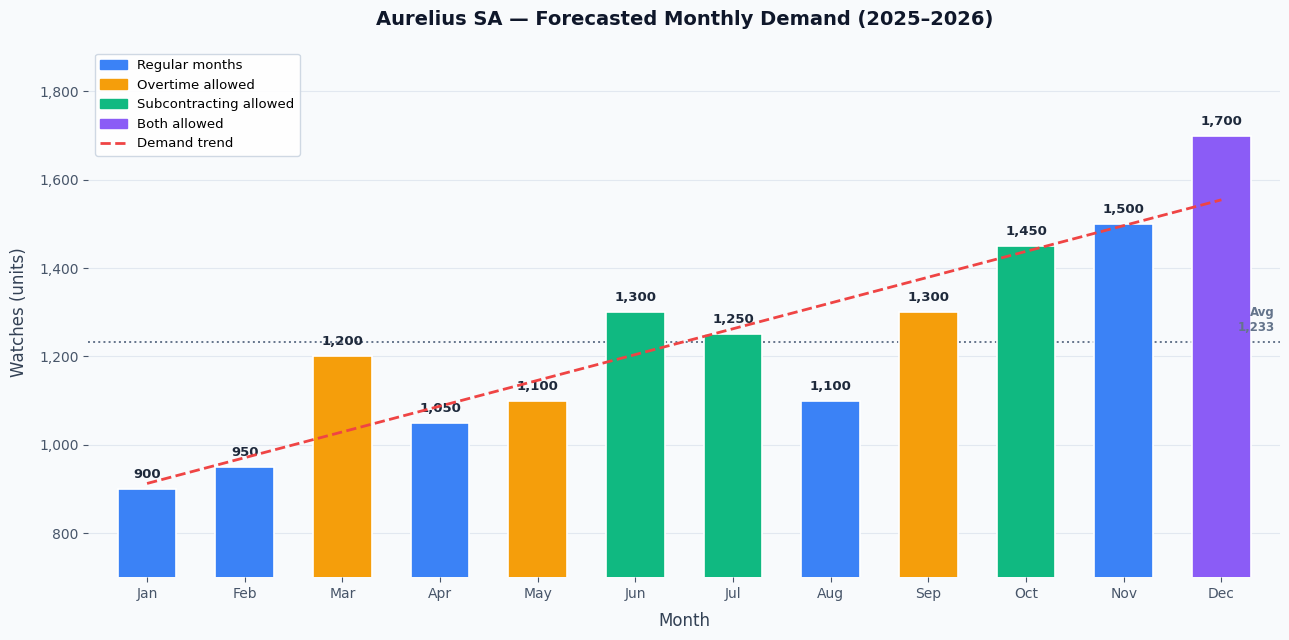

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Data
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
demand = [900, 950, 1200, 1050, 1100, 1300,
          1250, 1100, 1300, 1450, 1500, 1700]

# Overtime and subcontracting months (1-indexed)
overtime_months = {3, 5, 9, 12}       # Mar, May, Sep, Dec
subcontracting_months = {6, 7, 10, 12} # Jun, Jul, Oct, Dec

# Color each bar
colors = []
for i in range(1, 13):
    if i in overtime_months and i in subcontracting_months:
        colors.append("#8B5CF6")   # purple = both
    elif i in overtime_months:
        colors.append("#F59E0B")   # amber = overtime
    elif i in subcontracting_months:
        colors.append("#10B981")   # green = subcontracting
    else:
        colors.append("#3B82F6")   # blue = regular

fig, ax = plt.subplots(figsize=(13, 6.5))
fig.patch.set_facecolor("#F8FAFC")
ax.set_facecolor("#F8FAFC")

# Bars
bars = ax.bar(months, demand, color=colors, width=0.6,
              edgecolor="white", linewidth=1.2, zorder=3)

# Trend line
x_num = np.arange(len(months))
z = np.polyfit(x_num, demand, 1)
p = np.poly1d(z)
ax.plot(months, p(x_num), color="#EF4444", linewidth=2,
        linestyle="--", zorder=4, label="Trend")

# Value labels on bars
for bar, val in zip(bars, demand):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 18,
            f"{val:,}", ha="center", va="bottom",
            fontsize=9.5, fontweight="bold", color="#1E293B")

# Reference line: average demand
avg = sum(demand) / len(demand)
ax.axhline(avg, color="#64748B", linewidth=1.4,
           linestyle=":", zorder=2)
ax.text(11.55, avg + 18, f"Avg\n{avg:,.0f}",
        ha="right", va="bottom", fontsize=8.5,
        color="#64748B", fontweight="bold")

# Axes styling
ax.set_ylim(700, 1900)
ax.set_xlim(-0.6, 11.6)
ax.set_xlabel("Month", fontsize=12, color="#334155", labelpad=8)
ax.set_ylabel("Watches (units)", fontsize=12, color="#334155", labelpad=8)
ax.set_title("Aurelius SA — Forecasted Monthly Demand (2025–2026)",
             fontsize=14, fontweight="bold", color="#0F172A", pad=16)

ax.tick_params(colors="#475569", labelsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, color="#E2E8F0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# Legend
legend_items = [
    mpatches.Patch(color="#3B82F6", label="Regular months"),
    mpatches.Patch(color="#F59E0B", label="Overtime allowed"),
    mpatches.Patch(color="#10B981", label="Subcontracting allowed"),
    mpatches.Patch(color="#8B5CF6", label="Both allowed"),
    plt.Line2D([0], [0], color="#EF4444", linewidth=2,
               linestyle="--", label="Demand trend"),
]
ax.legend(handles=legend_items, loc="upper left",
          frameon=True, framealpha=0.9, fontsize=9.5,
          edgecolor="#CBD5E1")

plt.tight_layout()

print("Saved.")
